# Test du Dataset Motion Flow
Ce notebook permet de visualiser un exemple du dataset `LandscapeMotionDataset`.
Il charge le dataset, sélectionne une paire au hasard, et l'affiche. Pour mieux percevoir le mouvement subtil entre les frames, la différence absolue amplifiée est également affichée.

In [1]:
import sys
import os
import matplotlib.pyplot as plt
import random
import torch

# Ajout du dossier racine au sys.path pour retrouver le module 'src'
sys.path.append(os.path.abspath('..'))

from data.dataset import LandscapeMotionDataset

In [2]:
# Définir le chemin vers le dataset
DATA_DIR = "../data/youtube_landscape"

try:
    dataset = LandscapeMotionDataset(DATA_DIR)
    print(f"✓ Dataset chargé avec succès ! Nombre total de paires : {len(dataset)}")
except Exception as e:
    print(f"❌ Erreur lors du chargement du dataset : {e}")

✓ Dataset chargé avec succès ! Nombre total de paires : 1000


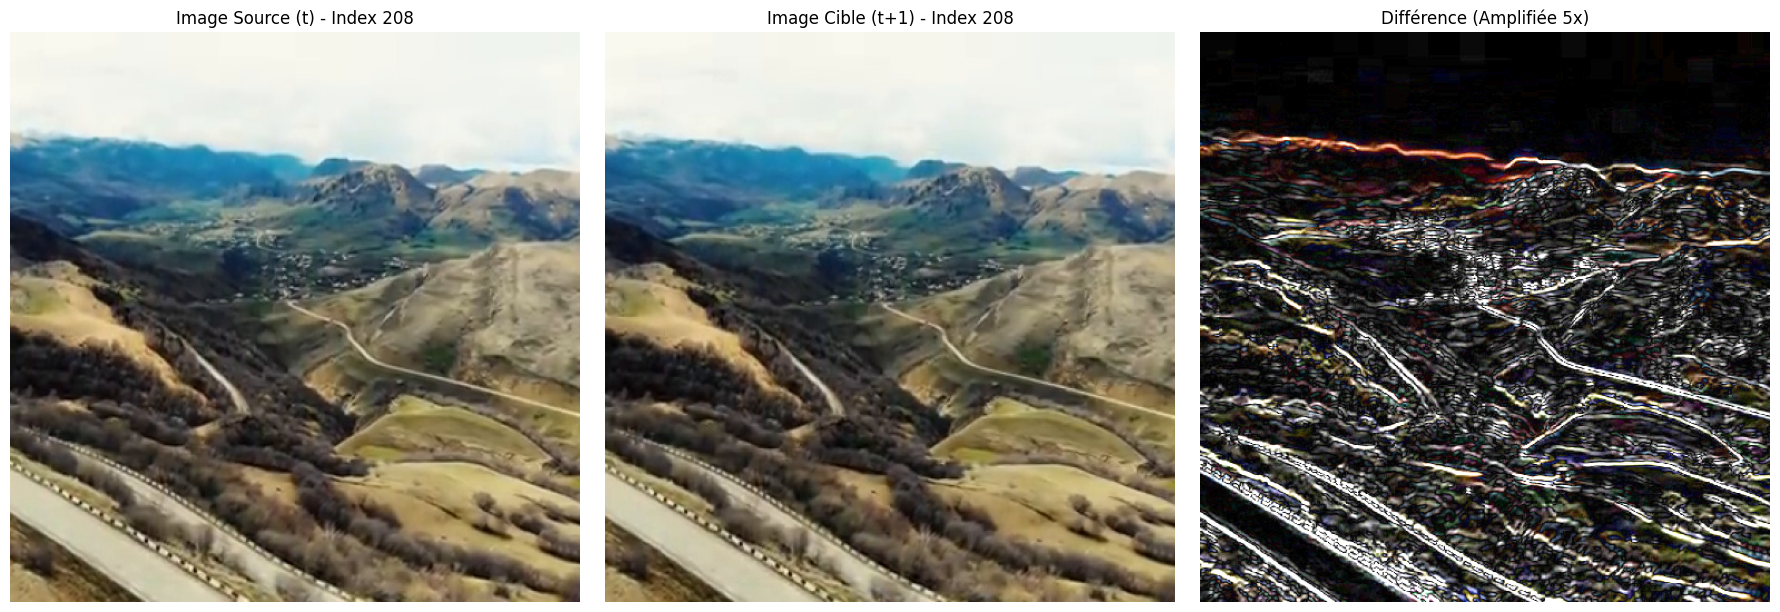

In [3]:
if 'dataset' in locals() and len(dataset) > 0:
    # Sélectionner un index aléatoire
    idx = random.randint(0, len(dataset) - 1)
    
    # Extraire les images
    img_A, img_B = dataset[idx]
    
    # Si ce sont des Tensors (C, H, W), on les passe en (H, W, C) pour matplotlib
    if isinstance(img_A, torch.Tensor):
        img_A_np = img_A.permute(1, 2, 0).numpy()
        img_B_np = img_B.permute(1, 2, 0).numpy()
    else:
        import numpy as np
        img_A_np = np.array(img_A)
        img_B_np = np.array(img_B)
        
    # Normalisation pour l'affichage avec imshow (valeurs entre 0.0 et 1.0)
    def normalize_for_display(img_array):
        img_min = img_array.min()
        img_max = img_array.max()
        if img_min < 0 or img_max > 1:
            return (img_array - img_min) / (img_max - img_min + 1e-5)
        return img_array

    img_A_disp = normalize_for_display(img_A_np)
    img_B_disp = normalize_for_display(img_B_np)
    
    # Calcul de la différence absolue (amplifiée pour mieux voir le mouvement)
    import numpy as np
    diff = np.abs(img_B_disp - img_A_disp) * 5.0 # Amplifié 5x
    diff = np.clip(diff, 0, 1)

    # Afficher côte à côte et la différence
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(img_A_disp)
    axes[0].set_title(f"Image Source (t) - Index {idx}")
    axes[0].axis('off')
    
    axes[1].imshow(img_B_disp)
    axes[1].set_title(f"Image Cible (t+1) - Index {idx}")
    axes[1].axis('off')
    
    axes[2].imshow(diff)
    axes[2].set_title("Différence (Amplifiée 5x)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Veuillez vérifier que le dataset est bien chargé.")

## Visualisation du Motion Flow (Estimation avec OpenCV)
Comme tu l'as remarqué, la différence absolue n'est **pas** le *Motion Flow*. La différence de pixels montre juste où les couleurs ont changé d'une frame à l'autre. Le Motion Flow, quant à lui, représente la **direction et la force du mouvement** (x, y) de chaque objet/pixel.

Puisque nous sommes sur des images réelles de YouTube (sans "Ground Truth"), nous allons l'estimer avec un algorithme classique d'OpenCV (la méthode de Farneback) pour te montrer à quoi ressemblent les vecteurs $U$ (déplacement horizontal) et $V$ (déplacement vertical).

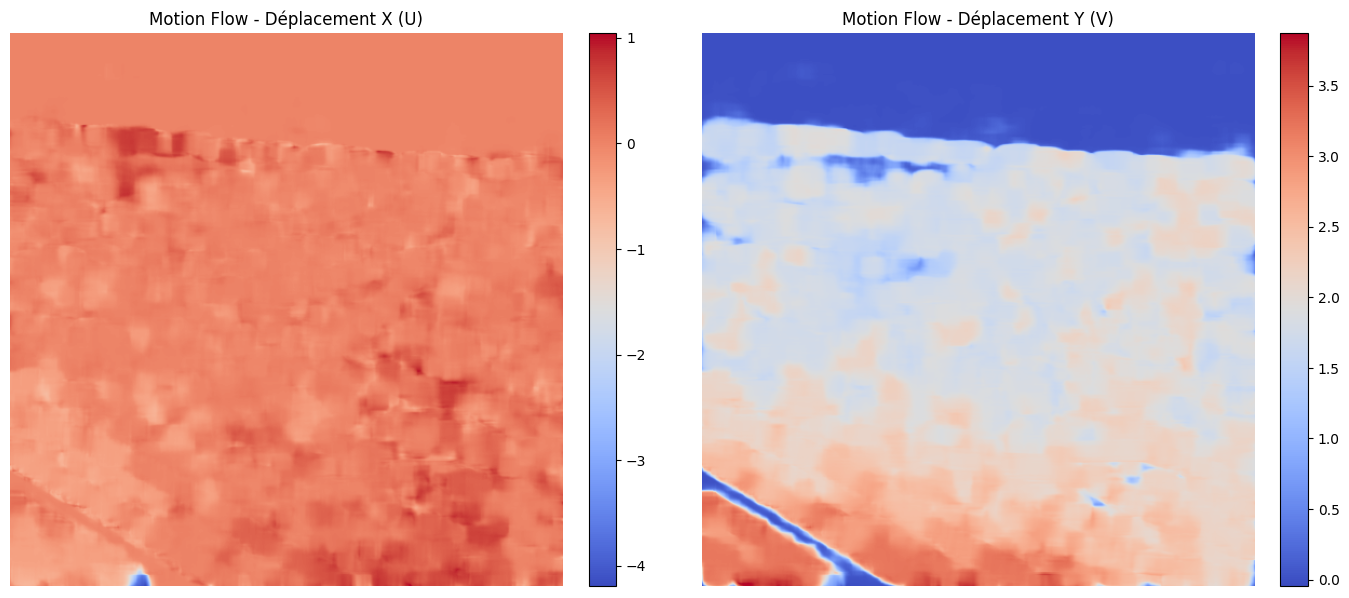

In [4]:
import cv2
import numpy as np

if 'dataset' in locals() and len(dataset) > 0:
    # img_A_disp et img_B_disp sont normalisées dans [0, 1] pour matplotlib
    # On les convertit en uint8 [0, 255] pour OpenCV
    gray_A = (img_A_disp * 255).astype(np.uint8)
    gray_B = (img_B_disp * 255).astype(np.uint8)
    
    # Passage en niveaux de gris si l'image est en RGB
    if len(gray_A.shape) == 3:
        gray_A = cv2.cvtColor(gray_A, cv2.COLOR_RGB2GRAY)
        gray_B = cv2.cvtColor(gray_B, cv2.COLOR_RGB2GRAY)
        
    # Calcul du dense optical flow par la méthode de Farneback
    # On obtient une matrice (H, W, 2) contenant le déplacement (U, V) pour chaque pixel
    flow = cv2.calcOpticalFlowFarneback(gray_A, gray_B, None, 
                                      pyr_scale=0.5, levels=3, winsize=15, 
                                      iterations=3, poly_n=5, poly_sigma=1.2, flags=0)
                                      
    flow_x = flow[..., 0] # U
    flow_y = flow[..., 1] # V
    
    # Affichage du flux
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # U: Mouvement selon l'axe X
    im0 = axes[0].imshow(flow_x, cmap='coolwarm')
    axes[0].set_title("Motion Flow - Déplacement X (U)")
    axes[0].axis('off')
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    
    # V: Mouvement selon l'axe Y
    im1 = axes[1].imshow(flow_y, cmap='coolwarm')
    axes[1].set_title("Motion Flow - Déplacement Y (V)")
    axes[1].axis('off')
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
else:
    print("Veuillez charger le dataset et afficher une paire d'abord.")